# Importando librerias

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Cargando Dataset

In [2]:
conn = sqlite3.connect('jobs.db')

query = "SELECT * FROM jobs_cleaned_table WHERE (job_group='Data Scientist' OR job_group='Data Analyst' OR job_group='Data Engineer' or job_group='Business Intelligence')"
df = pd.read_sql_query(query,conn)

df['date_posted'] = pd.to_datetime(df['date_posted'].str.split().str[0], errors='coerce').dt.strftime('%Y-%m-%d')

conn.close()

# EDA inicial

In [3]:
df.head()

,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,...,state,country,city_state,min_salary,max_salary,mean_salary,experience,education,programming_languages,languages
0,in-e3f5ff10ddfb793f,indeed,https://pe.indeed.com/viewjob?jk=e3f5ff10ddfb793f,https://jobs.lever.co/bluelightconsulting/19e2...,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,"Piura, PIU, PE",2026-03-08,fulltime,None,...,PIU,PE,"Piura,PIU",None,None,None,2,None,"CSS, JavaScript, SQL, DAX, R",
1,in-24a42716e0f8e687,indeed,https://pe.indeed.com/viewjob?jk=24a42716e0f8e687,https://jobs.lever.co/bluelightconsulting/a7cf...,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,"Iquitos, LOR, PE",2026-03-08,fulltime,None,...,LOR,PE,"Iquitos,LOR",None,None,None,2,None,"CSS, JavaScript, SQL, DAX, R",
2,in-e9fe9bf8d40f74a7,indeed,https://pe.indeed.com/viewjob?jk=e9fe9bf8d40f74a7,https://jobs.lever.co/bluelightconsulting/8c19...,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,"Lima, LIM, PE",2026-03-08,fulltime,None,...,LIM,PE,"Lima,LIM",None,None,None,2,None,"CSS, JavaScript, SQL, DAX, R",
3,in-5bd2aebc71bcf7ed,indeed,https://pe.indeed.com/viewjob?jk=5bd2aebc71bcf7ed,https://jobs.lever.co/bluelightconsulting/47c0...,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,"Trujillo, LLI, PE",2026-03-08,fulltime,None,...,LLI,PE,"Trujillo,LLI",None,None,None,2,None,"CSS, JavaScript, SQL, DAX, R",
4,in-cffb69b02a30272a,indeed,https://pe.indeed.com/viewjob?jk=cffb69b02a30272a,https://jobs.lever.co/bluelightconsulting/8d52...,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,"Arequipa, ARE, PE",2026-03-08,fulltime,None,...,ARE,PE,"Arequipa,ARE",None,None,None,2,None,"CSS, JavaScript, SQL, DAX, R",


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     54 non-null     object
 1   site                   54 non-null     object
 2   job_url                54 non-null     object
 3   job_url_direct         54 non-null     object
 4   title                  54 non-null     object
 5   company                53 non-null     object
 6   location               54 non-null     object
 7   date_posted            54 non-null     object
 8   job_type               47 non-null     object
 9   salary_source          0 non-null      object
 10  interval               0 non-null      object
 11  min_amount             0 non-null      object
 12  max_amount             0 non-null      object
 13  currency               0 non-null      object
 14  is_remote              54 non-null     int64 
 15  job_level              0 

In [5]:
df.describe(include='all')

,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,...,state,country,city_state,min_salary,max_salary,mean_salary,experience,education,programming_languages,languages
count,54,54,54,54,54,53,54,54,47,0,...,47,54,47,0,0,0,54.000000,10,54,54
unique,54,1,54,54,42,36,18,25,1,0,...,13,1,17,0,0,0,NaN,3,9,4
top,in-e3f5ff10ddfb793f,indeed,https://pe.indeed.com/viewjob?jk=e3f5ff10ddfb793f,https://jobs.lever.co/bluelightconsulting/19e2...,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,"Lima, LIM, PE",2026-03-08,fulltime,NaN,...,LIM,PE,"Lima,LIM",NaN,NaN,NaN,NaN,Bachelor,,
freq,1,54,1,1,10,10,25,10,47,NaN,...,32,54,25,NaN,NaN,NaN,NaN,7,20,40
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.777778,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.603819,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN


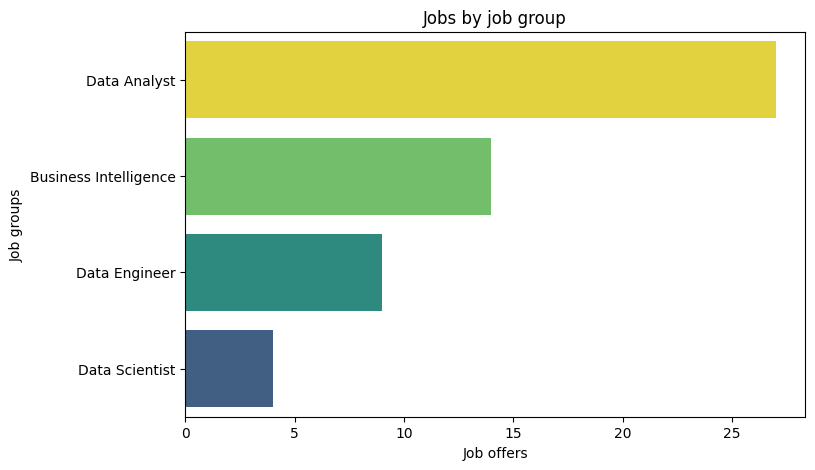

In [6]:
job_groups_counts = df['job_group'].value_counts()

def plot_bars(x,y,figsize=(8,5),title=None,xlabel=(None),ylabel=(None),palette=None):

    plt.figure(figsize=figsize)
    cmap = plt.cm.get_cmap(palette).reversed()
    palette = [cmap(x) for x in np.linspace(0,0.7,len(job_groups_counts))]

    sns.barplot(x=x,y=y,palette=palette)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_bars(x=job_groups_counts.values,y=job_groups_counts.index,title='Jobs by job group',xlabel='Job offers',ylabel='Job groups',palette='viridis')

# Análisis exploratorio de datos

## Lugar

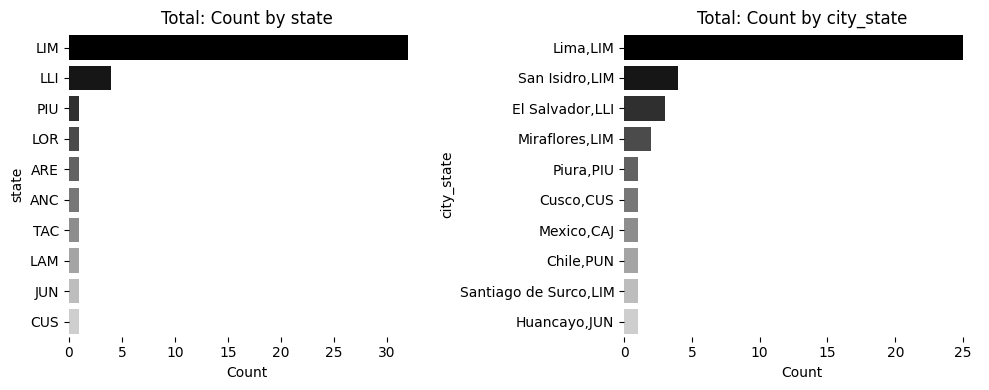

In [7]:
import sqlite3

def plot_multiple_bars(columns,category=None,figsize=(10,12),count_percentage=False,x_y=False,top_10=False,list_values=False,aggregate_column=None):

    rows = df[category].unique() if category is not None else ['Total']
    n_rows, n_cols = len(rows), len(columns)

    fig, axes = plt.subplots(n_rows,n_cols,figsize=figsize,squeeze=False)

    category_palettes = {
        'Data Analyst': 'Blues',
        'Data Engineer': 'Reds',
        'Data Scientist': 'Greens',
        'Business Intelligence': 'Purples',
    }

    for i, row in enumerate(rows):
        group_data = df[df[category] == row] if category is not None else df

        for j, column in enumerate(columns):

            if aggregate_column is None:
                if top_10 and list_values is False:
                    column_top = group_data[column].value_counts().head(10)
            
                elif list_values is not False and top_10 is None:
                    column_top=(group_data[column].str.split(', ').explode()
                                .value_counts()
                                .dropna()
                                .sort_values(ascending=False))
                    column_top = column_top.drop(labels='',errors='ignore')
                
                elif list_values is not False and top_10 is not None:
                    column_top=(group_data[column].str.split(', ').explode()
                                .value_counts()
                                .dropna()
                                .sort_values(ascending=False).head(10))
                    column_top = column_top.drop(labels='',errors='ignore')
                
                else:
                    column_top = group_data[column].value_counts()
            
            else:
                grouped =(
                    group_data.explode(column)
                    .groupby(column)[aggregate_column]
                    .mean()
                    .sort_values(ascending=False)
                )

                if list_values:
                    group_data = group_data.reset_index(drop=True)
                    grouped = pd.DataFrame({
                        column: group_data[column].str.split(', ').explode(),
                        aggregate_column: group_data[aggregate_column]
                    })
                    grouped = grouped.groupby(column)[aggregate_column].mean().sort_values(ascending=False)

                if '' in grouped.index:
                    grouped = grouped.drop('')
                
                column_top = grouped.head(10) if top_10 else grouped

            ax = axes[i,j]
            total = group_data[column].count()

            for spine in ax.spines.values():
                spine.set_visible(False)

            if category is not None:
                palette = category_palettes.get(row,'Blues')
                cmap = plt.cm.get_cmap(palette).reversed()
                palette = [cmap(x) for x in np.linspace(0,0.7,len(column_top))]

            else:
                cmap = plt.cm.get_cmap('Greys').reversed()
                palette = [cmap(x) for x in np.linspace(0,0.7,len(column_top))]

            kwargs ={
                'y':column_top.values,
                'x':column_top.index
            } if x_y else {
                'x':column_top.values,
                'y':column_top.index
            }

            sns.barplot(ax=ax,palette=palette, **kwargs)

            aggregate_label = 'Count' if aggregate_column is None else f'Avg{aggregate_column}'
            ax.set_title(f'{row}: {aggregate_label} by {column}')
            ax.set_xlabel(aggregate_label if not x_y else column)
            ax.set_ylabel(column if not x_y else aggregate_label)

            if count_percentage:
                for k, value in enumerate(column_top.values):
                    percentage = value/total*100
                    annotation_kwargs = {
                        'text': f'{value:.1f}({percentage:.1f}%)',
                        'xy':(k, value) if x_y else (value,k),
                        'xytext': (-30,5) if x_y else (5,0),
                        'textcoords': 'offset points',
                        'va':'center',
                        'ha':'left',
                        'fontsize':10,
                        'color':'black'
                    }
                    ax.annotate(**annotation_kwargs)
            
    plt.tight_layout()
    plt.show()

columns_location = ['state','city_state']

plot_multiple_bars(columns_location,figsize=(10,4),top_10=True)           


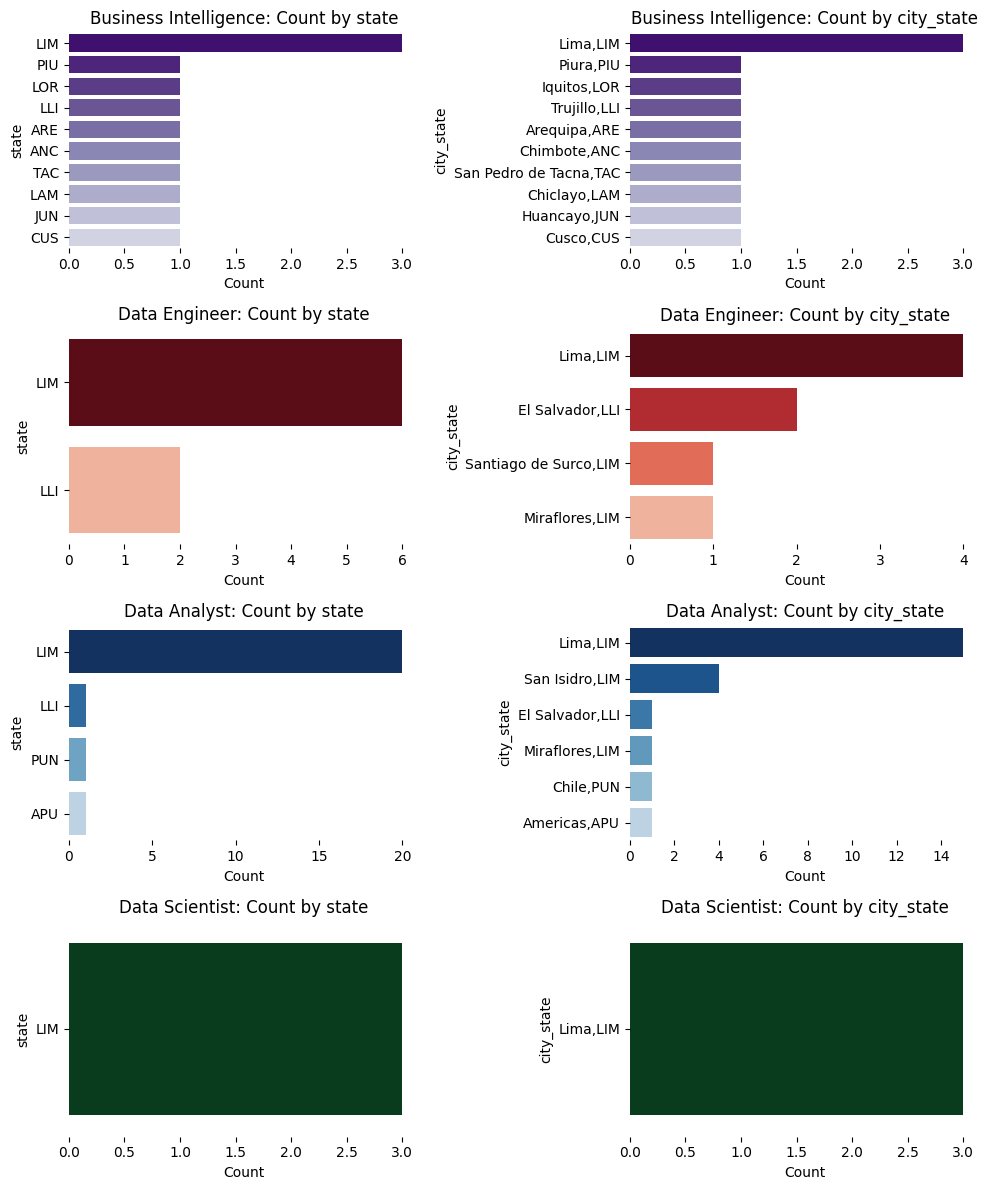

In [8]:
plot_multiple_bars(columns_location,category='job_group',figsize=(10,12),top_10=True)

## Niveles

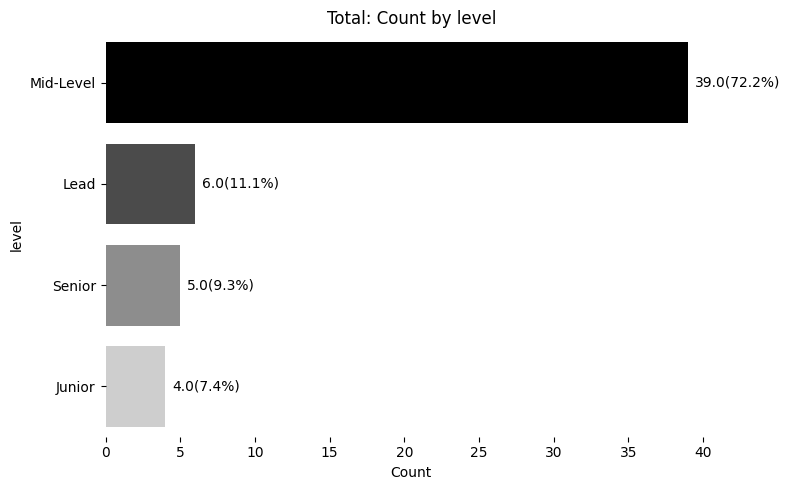

In [9]:
columns_level = ('level',)

plot_multiple_bars(columns_level,figsize=(8,5),count_percentage=True) 

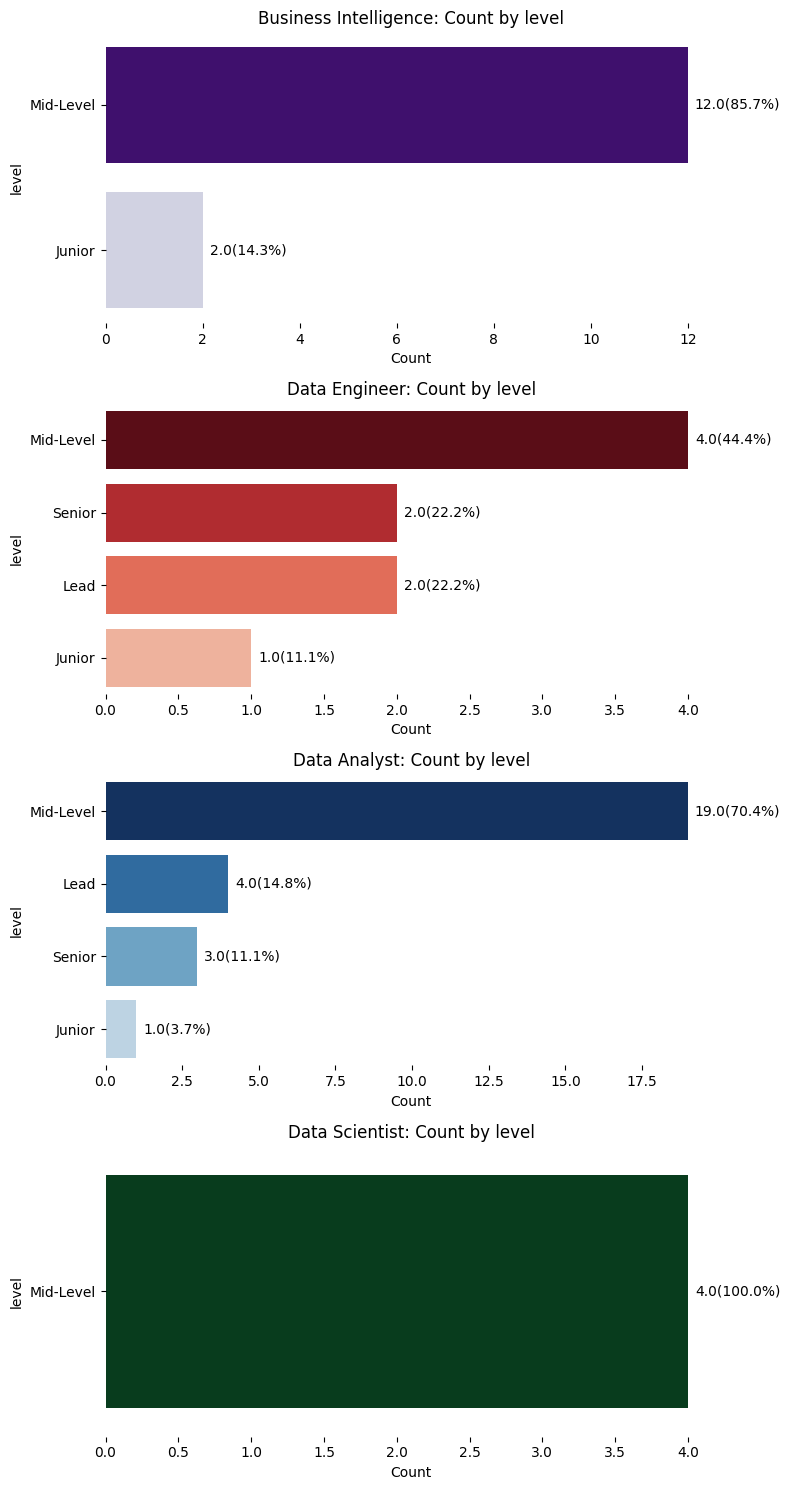

In [10]:
plot_multiple_bars(columns_level,category='job_group',figsize=(8,15),count_percentage=True)

## Experiencia

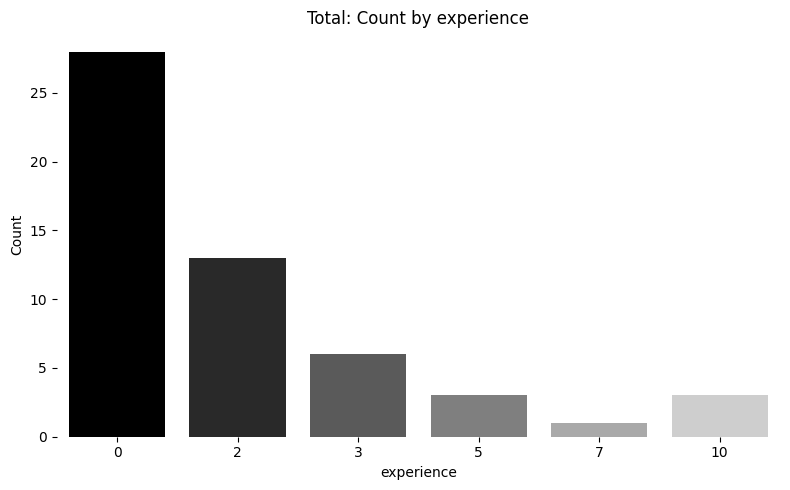

In [11]:
columns_experience = ('experience',)

plot_multiple_bars(columns_experience,figsize=(8,5),x_y=True)

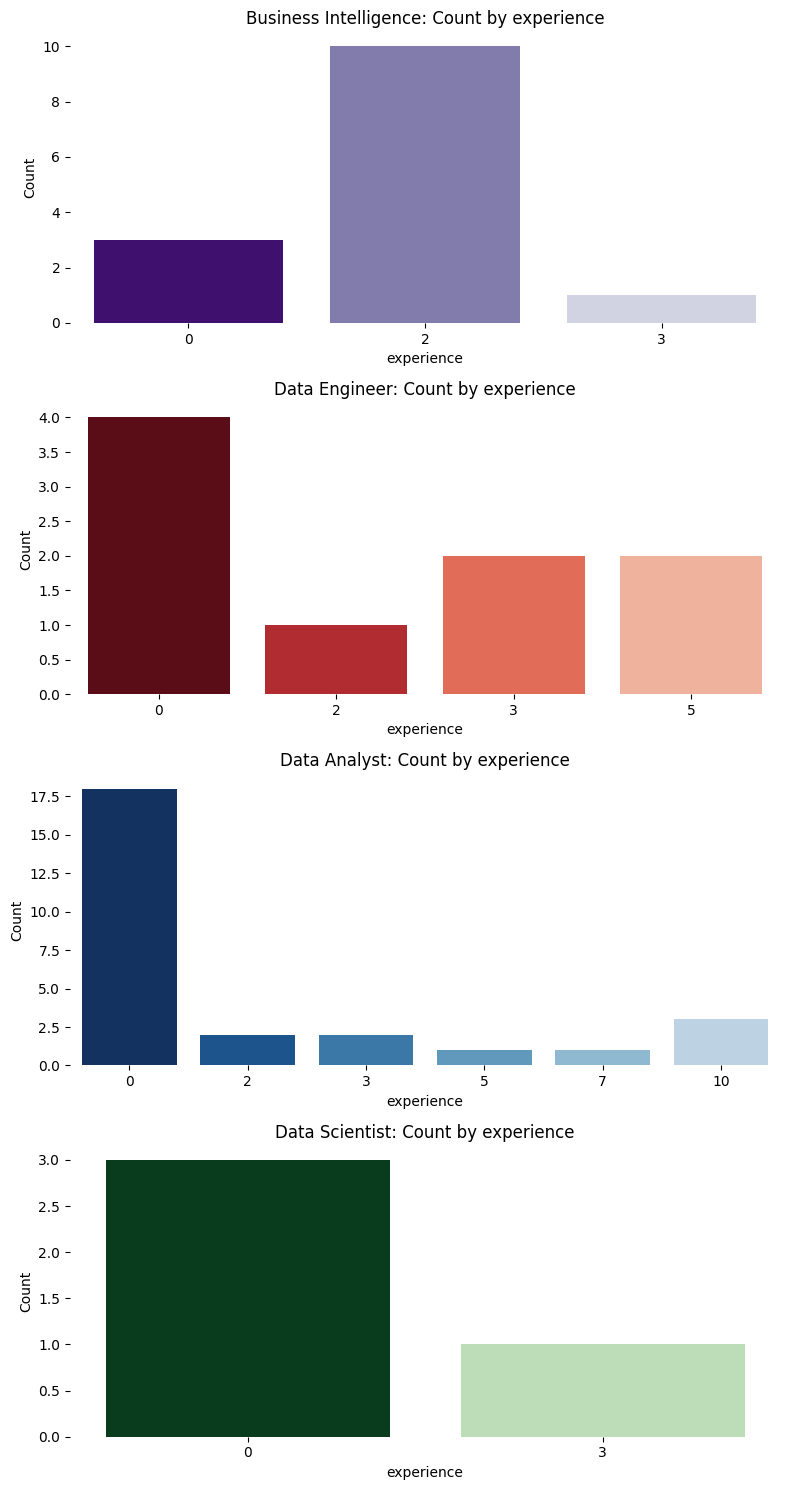

In [12]:
plot_multiple_bars(columns_experience,category='job_group',figsize=(8,15),x_y=True)

## Grado de educación

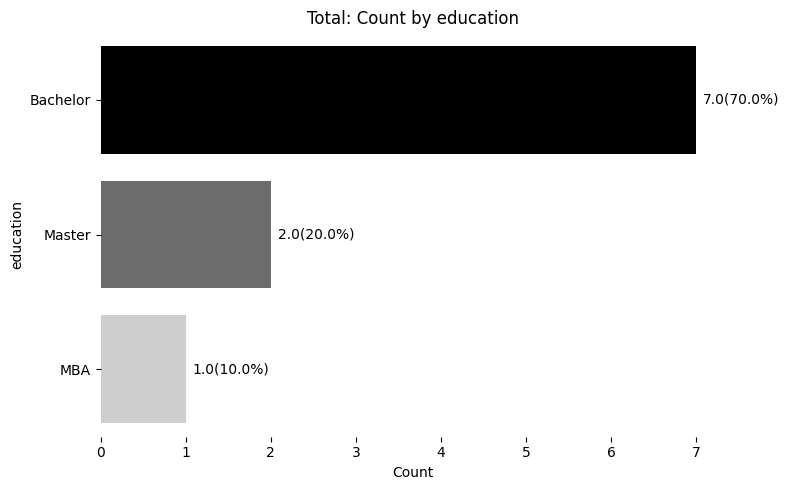

In [13]:
columns_education = ('education',)

plot_multiple_bars(columns_education,figsize=(8,5),count_percentage=True)

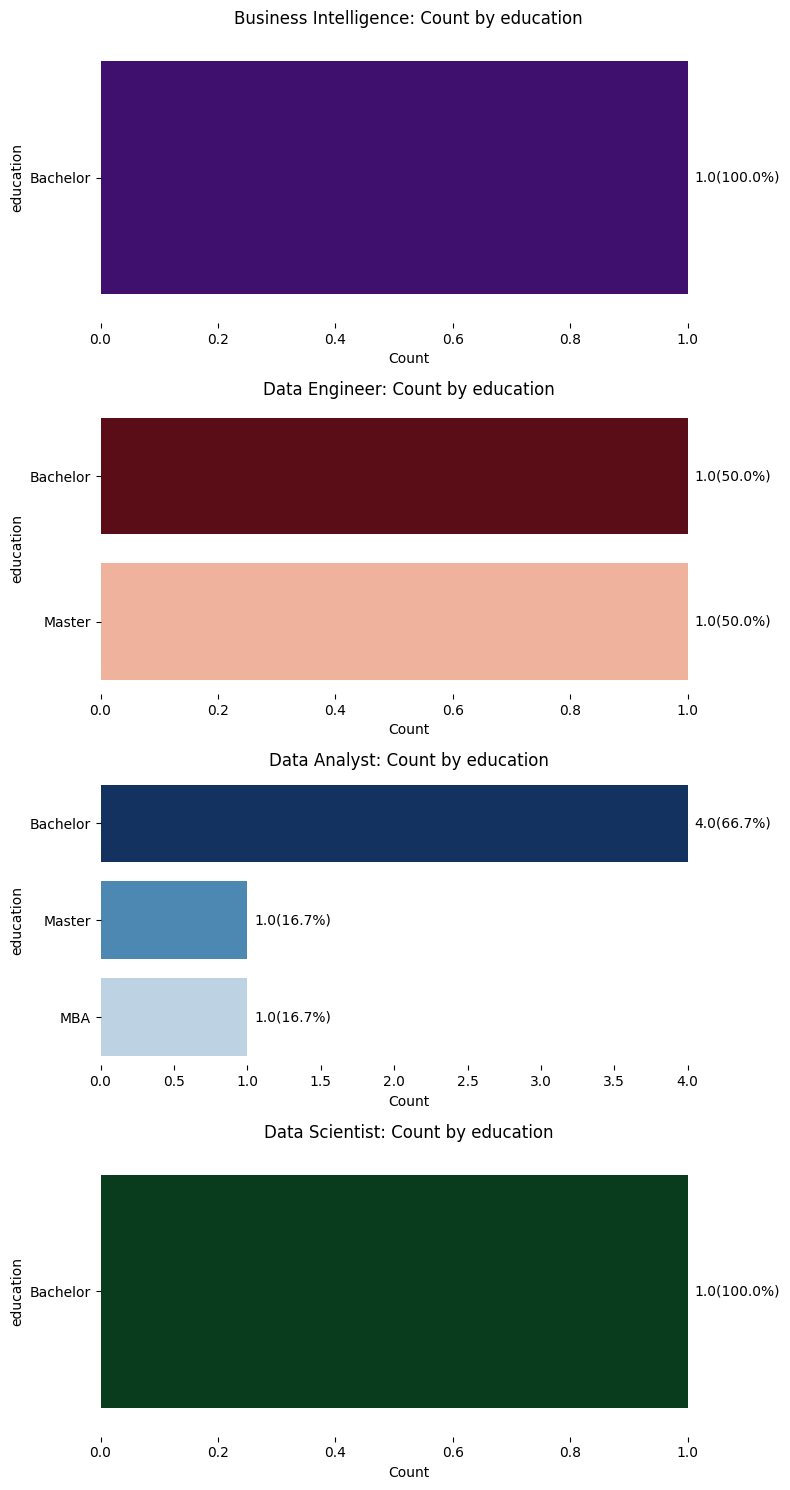

In [14]:
plot_multiple_bars(columns_education,category='job_group',figsize=(8,15),count_percentage=True)

## Habilidades

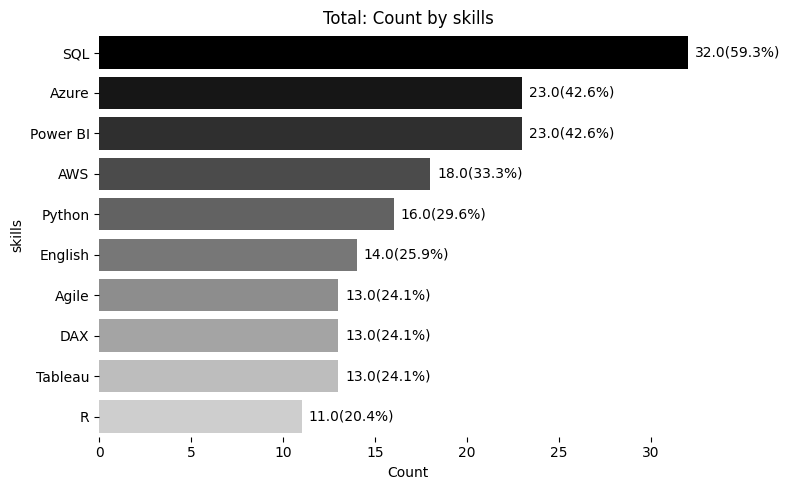

In [15]:
columns_skills = ['skills',]

plot_multiple_bars(columns_skills,figsize=(8,5),list_values=True,count_percentage=True)

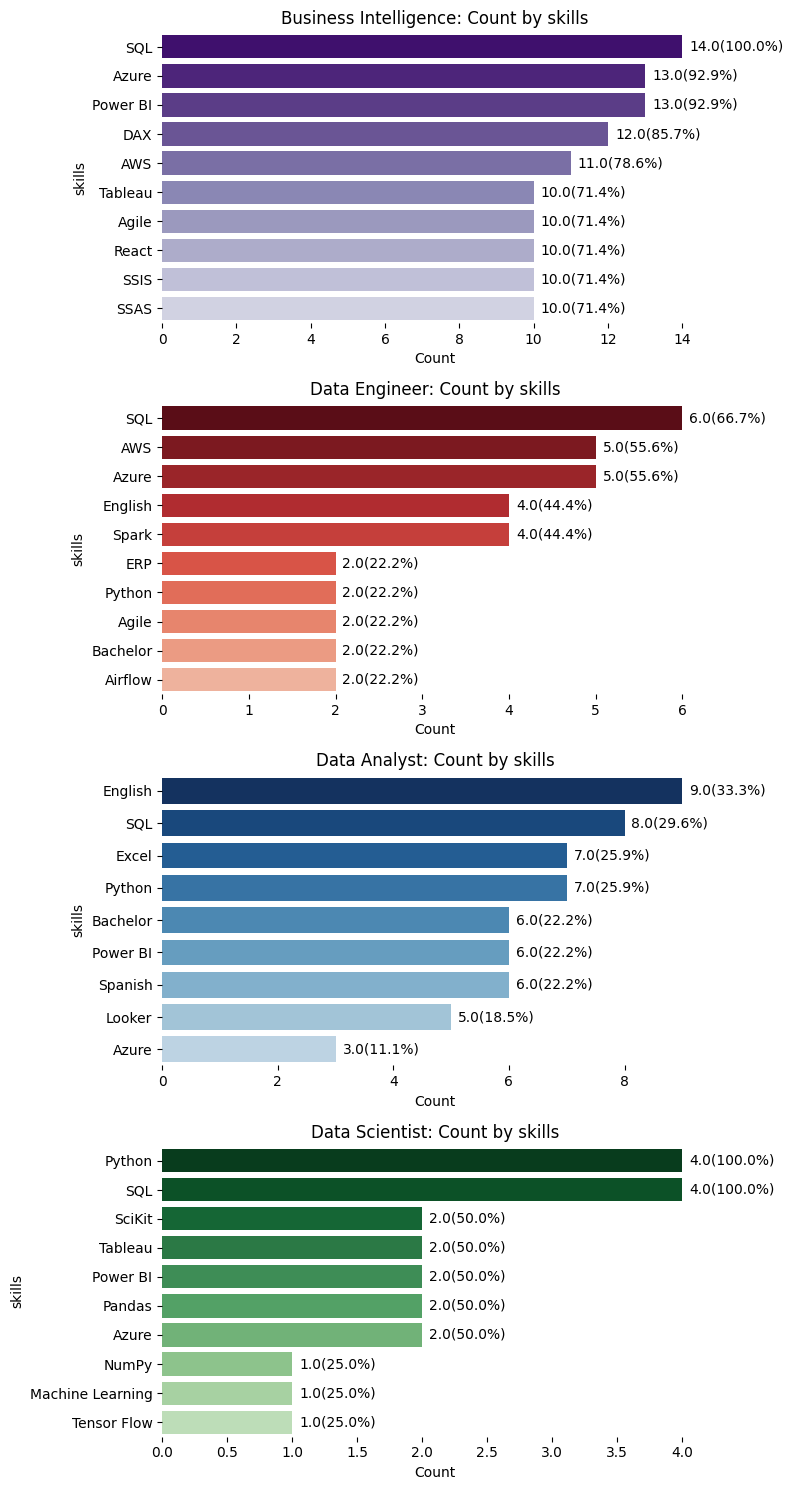

In [16]:
plot_multiple_bars(columns_skills,category='job_group',figsize=(8,15),list_values=True,count_percentage=True)

## Lenguajes de programación

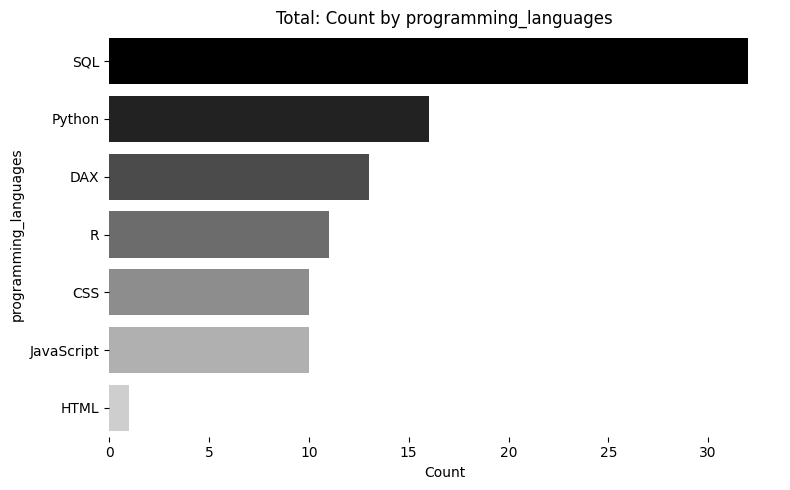

In [17]:
column_programming_language = ('programming_languages',)

plot_multiple_bars(column_programming_language,list_values=True,top_10=True,figsize=(8,5))

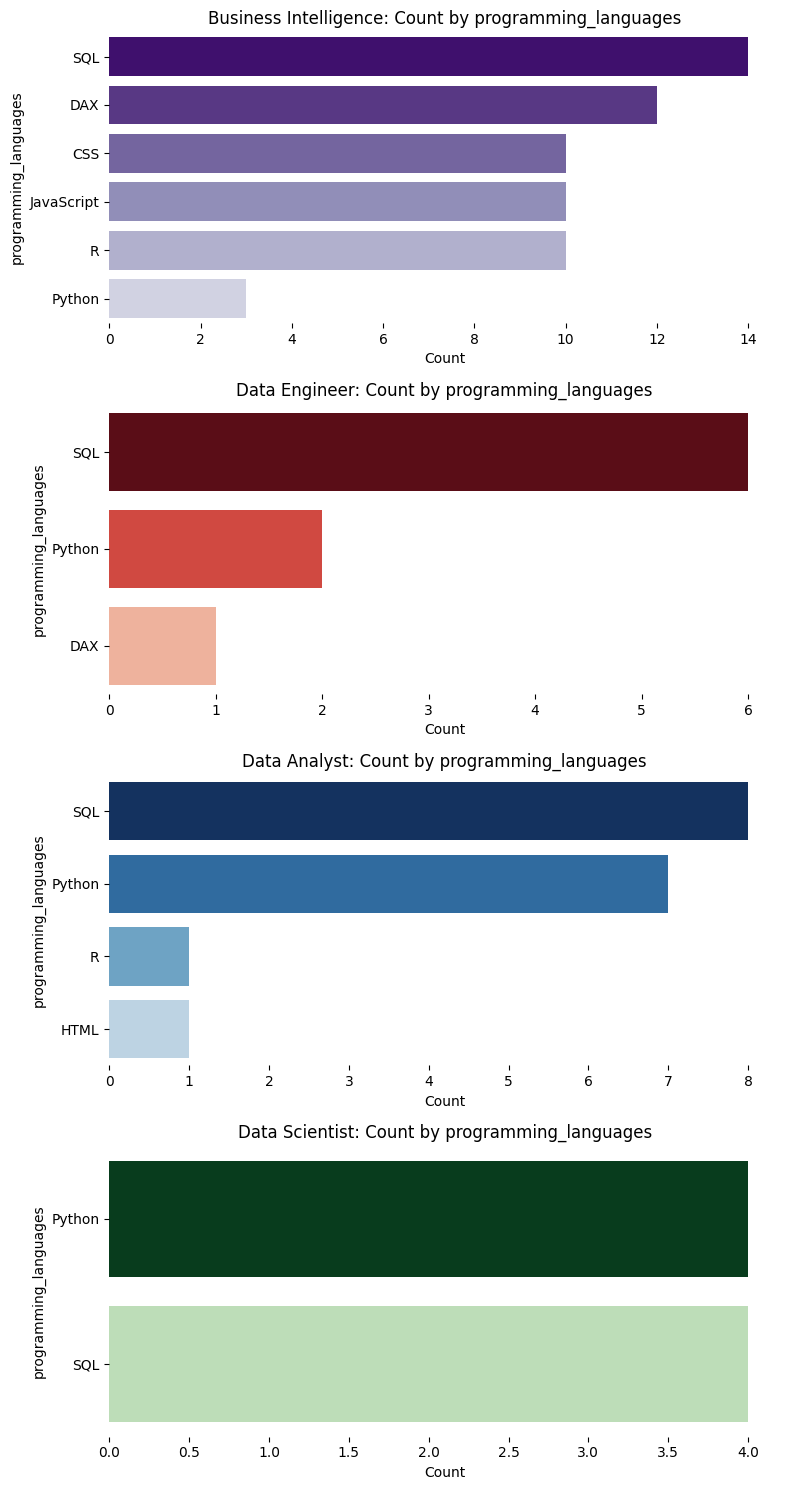

In [18]:
plot_multiple_bars(column_programming_language,category='job_group',list_values=True,top_10=True,figsize=(8,15))

## Idiomas mejor pagados

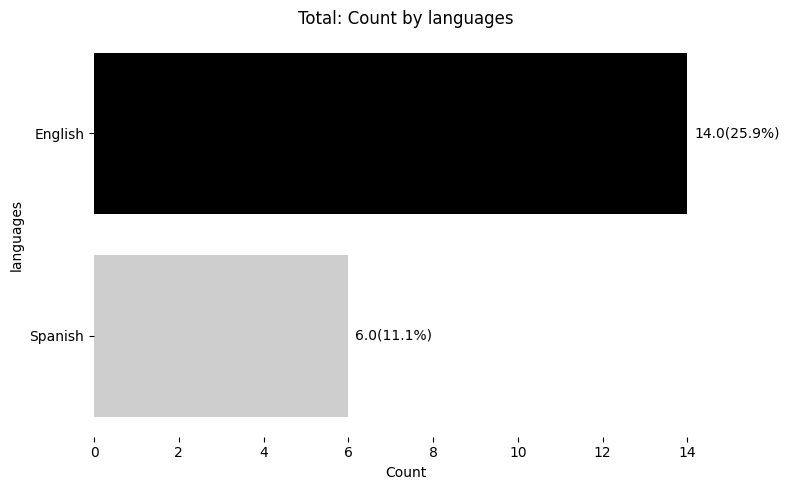

In [19]:
column_languages = ('languages',)

plot_multiple_bars(column_languages,list_values=True,figsize=(8,5),count_percentage=True)

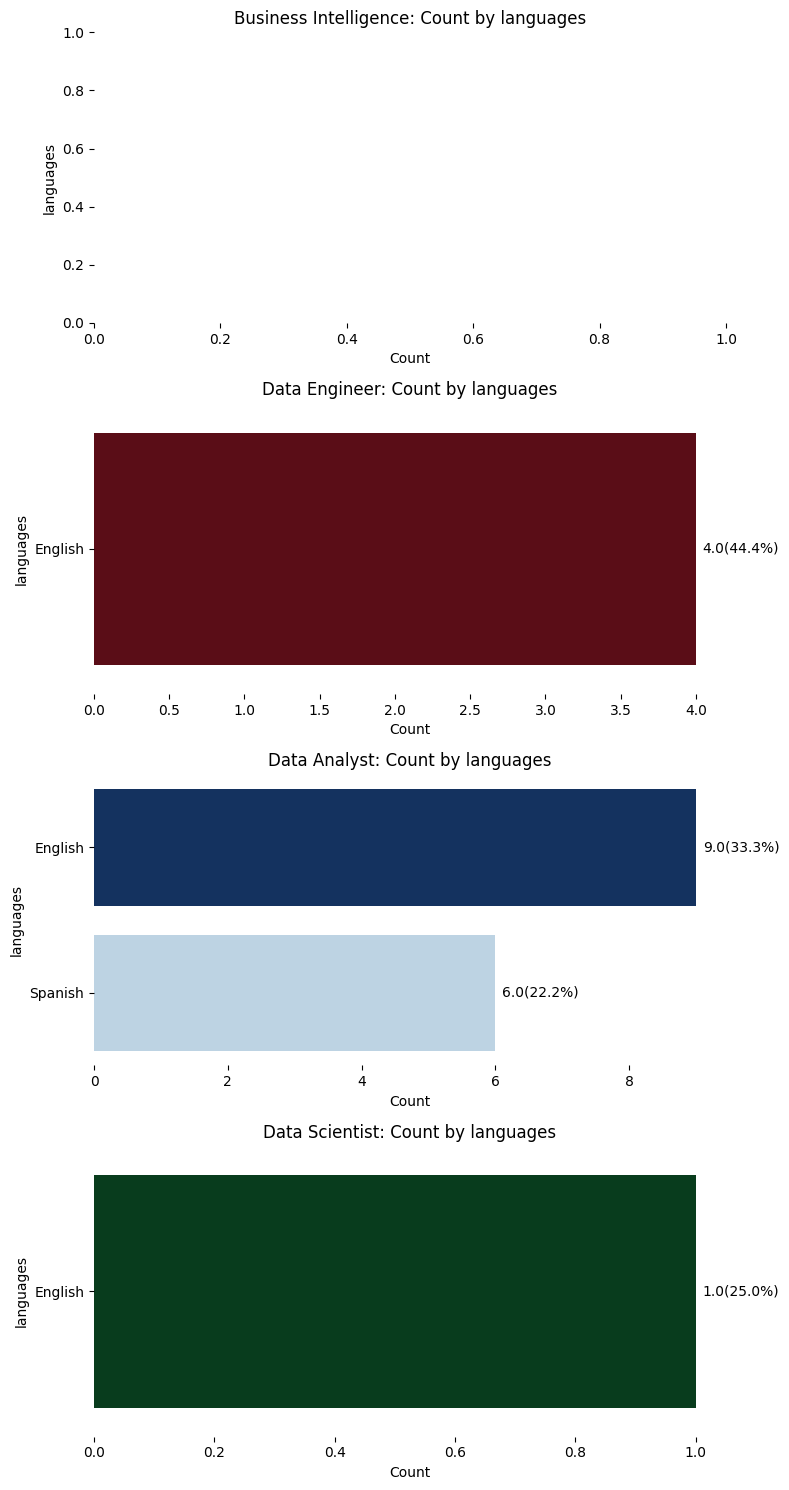

In [20]:
plot_multiple_bars(column_languages,category = 'job_group',list_values=True,figsize=(8,15),count_percentage=True)

# Análisis segun el salario

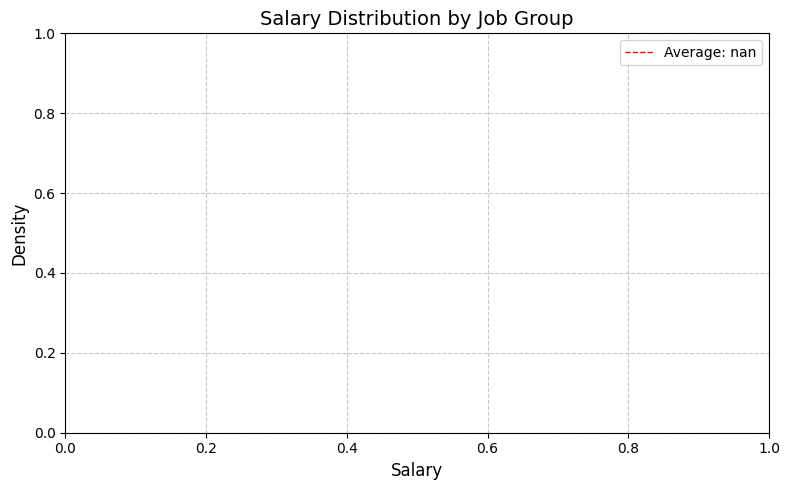

In [21]:
def plot_salary_kde(df,job_group_column=None,salary_column='salary',**kwargs):

    plt.figure(figsize=(8,5))

    if job_group_column:
        for job_group in df[job_group_column].unique():
            group_data = df[df[job_group_column] == job_group]

            mean_salary = group_data[salary_column].mean()

            sns.kdeplot(group_data[salary_column], shade=True, label=job_group, **kwargs)

            plt.axvline(mean_salary,color='red',linestyle='dashed',linewidth=1,label=f'Average:{mean_salary:.0f}')

            plt.title('Salary Distribution', fontsize = 14)

    else:

        mean_salary = df[salary_column].mean()

        sns.kdeplot(df[salary_column],shade=True,color='black',label='General', **kwargs)

        plt.axvline(mean_salary, color='red', linestyle='dashed', linewidth=1, label=f'Average: {mean_salary:.0f}')


        plt.title('Salary Distribution by Job Group', fontsize=14)

    
    plt.xlabel('Salary',fontsize=12)
    plt.ylabel('Density',fontsize=12)
    plt.legend(title=job_group_column if job_group_column else None)
    plt.grid(True,linestyle='--',alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_salary_kde(df,salary_column='mean_salary')

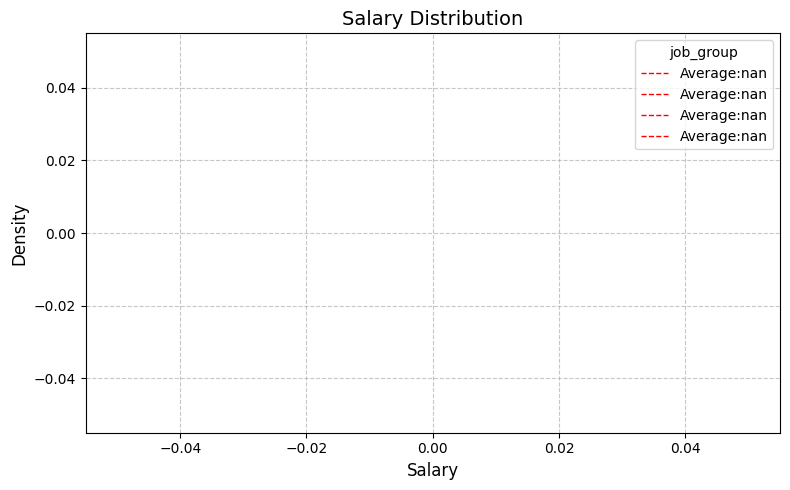

In [22]:
plot_salary_kde(df,job_group_column='job_group',salary_column='mean_salary')

## Lugares mejor remunerados

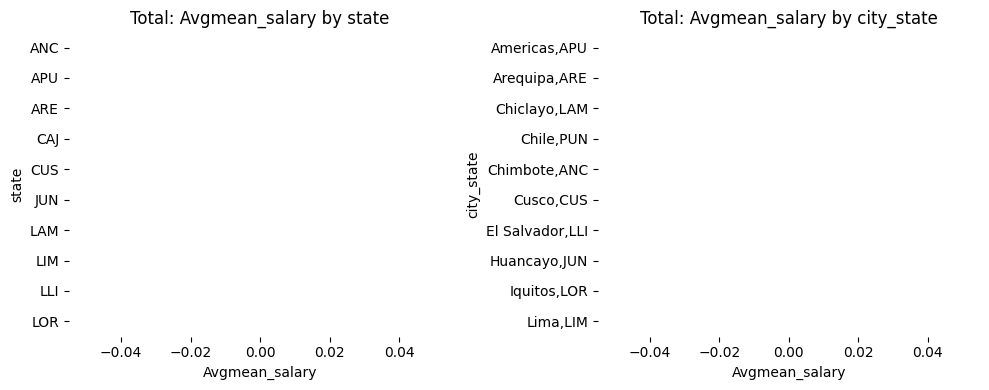

In [23]:
plot_multiple_bars(columns_location,figsize=(10,4),top_10=True,aggregate_column='mean_salary')

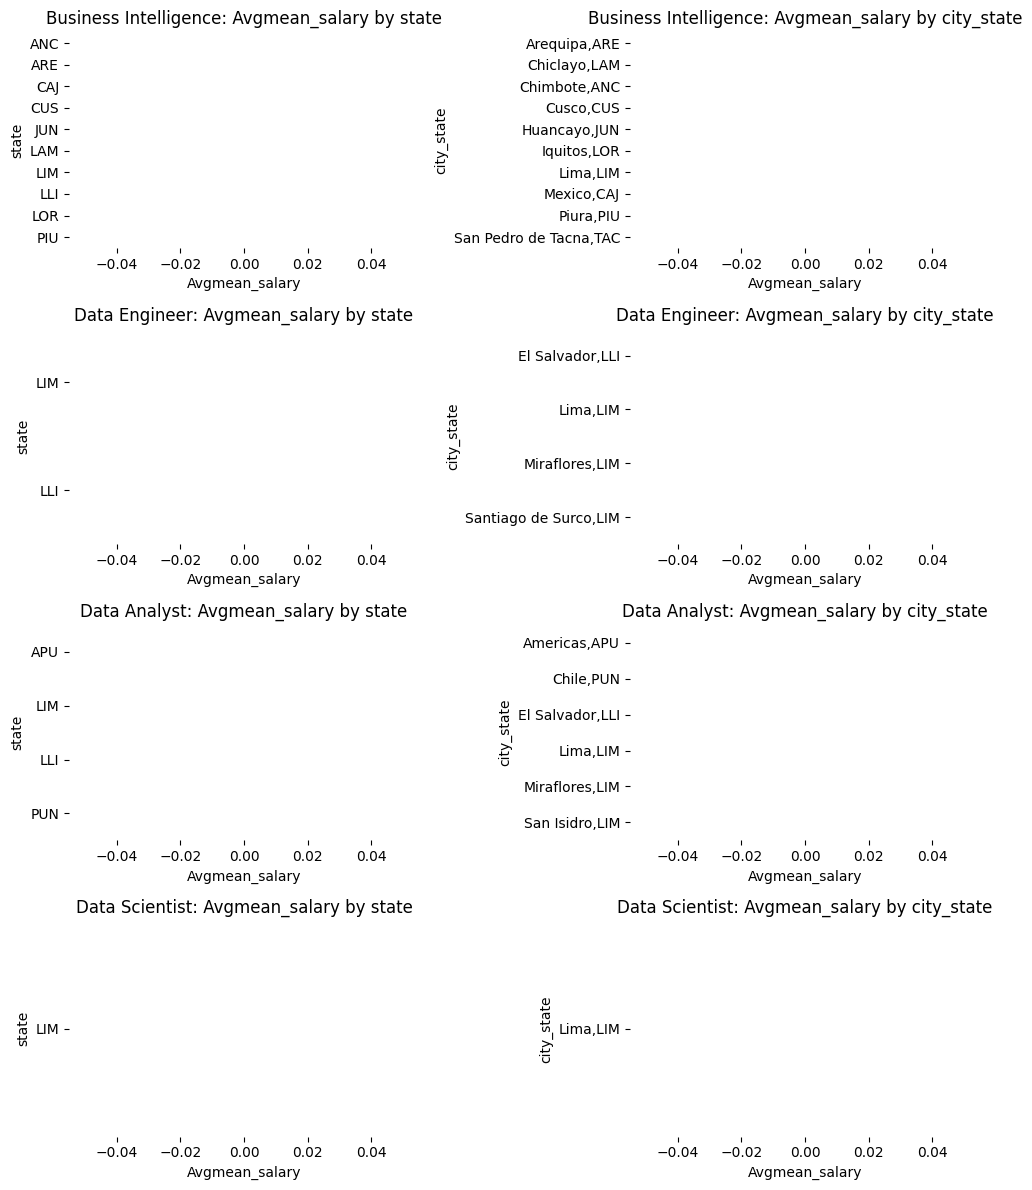

In [24]:
plot_multiple_bars(columns_location,category='job_group',figsize=(10,12),top_10=True,aggregate_column='mean_salary')

## Remuneracion segun el Nivel

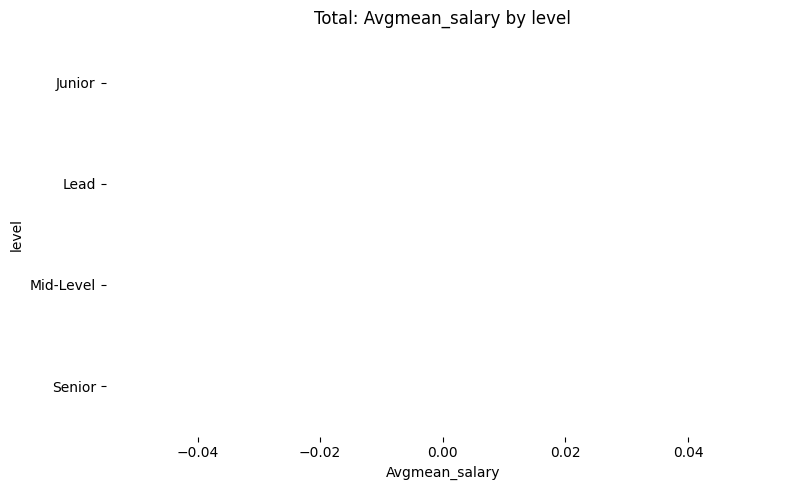

In [25]:
plot_multiple_bars(columns_level,figsize=(8,5),aggregate_column='mean_salary')

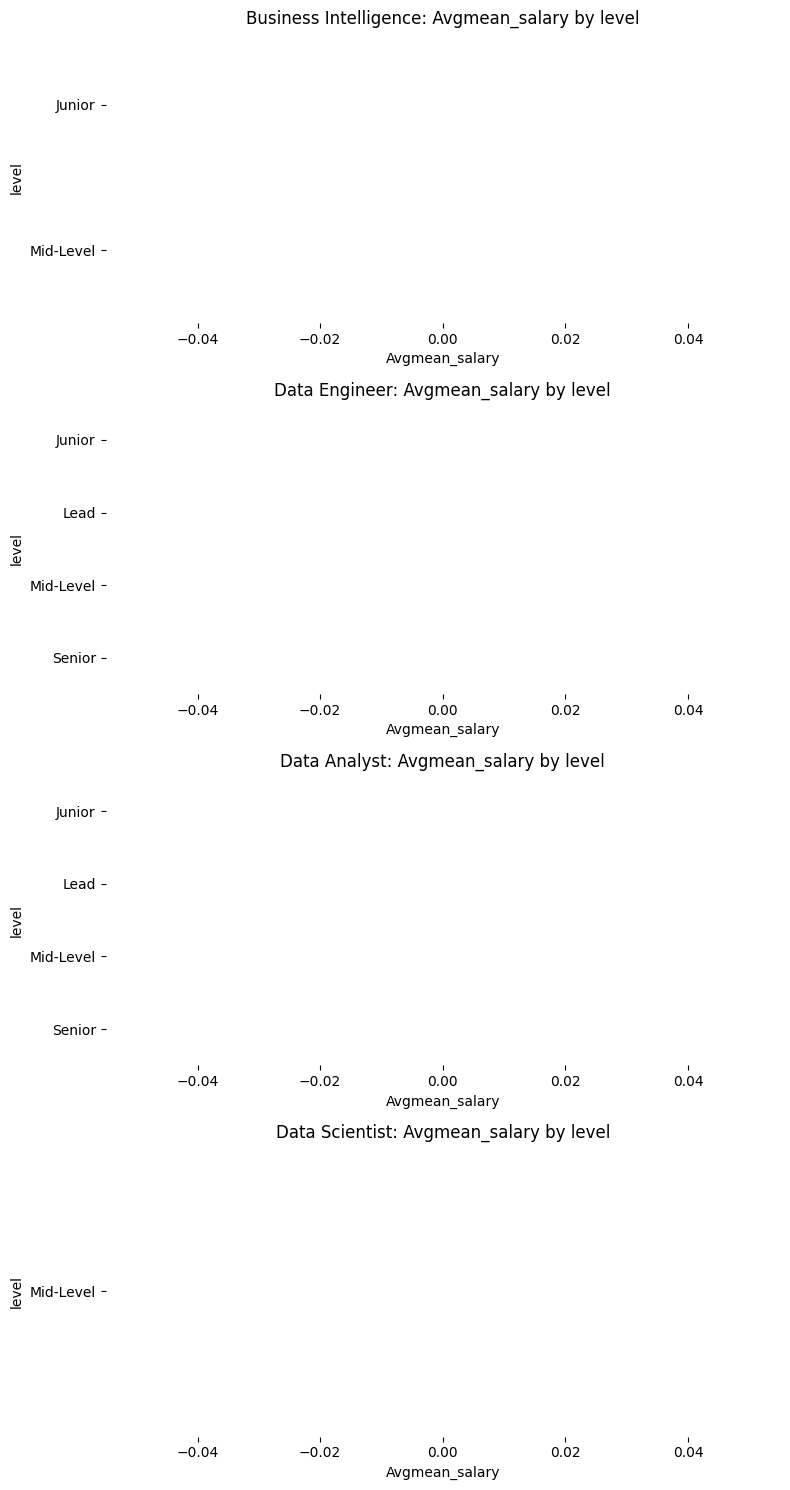

In [26]:
plot_multiple_bars(columns_level,category='job_group',figsize=(8,15),aggregate_column='mean_salary')

## Salario segun la Educacion

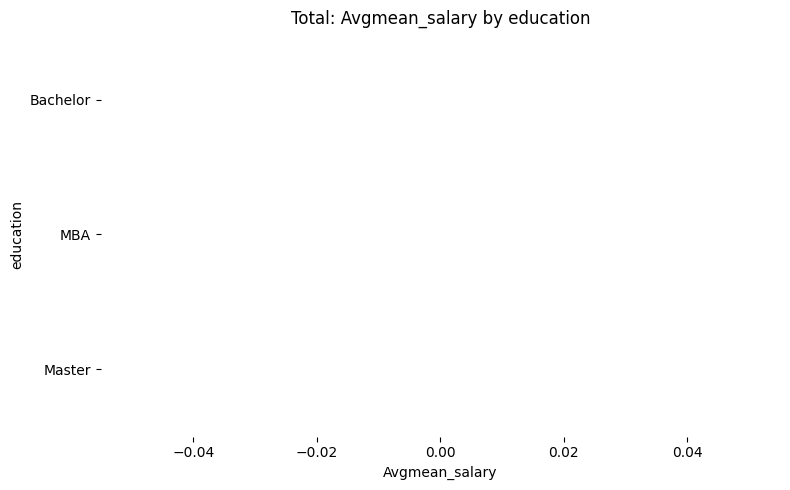

In [27]:
plot_multiple_bars(columns_education,figsize=(8,5),aggregate_column='mean_salary')

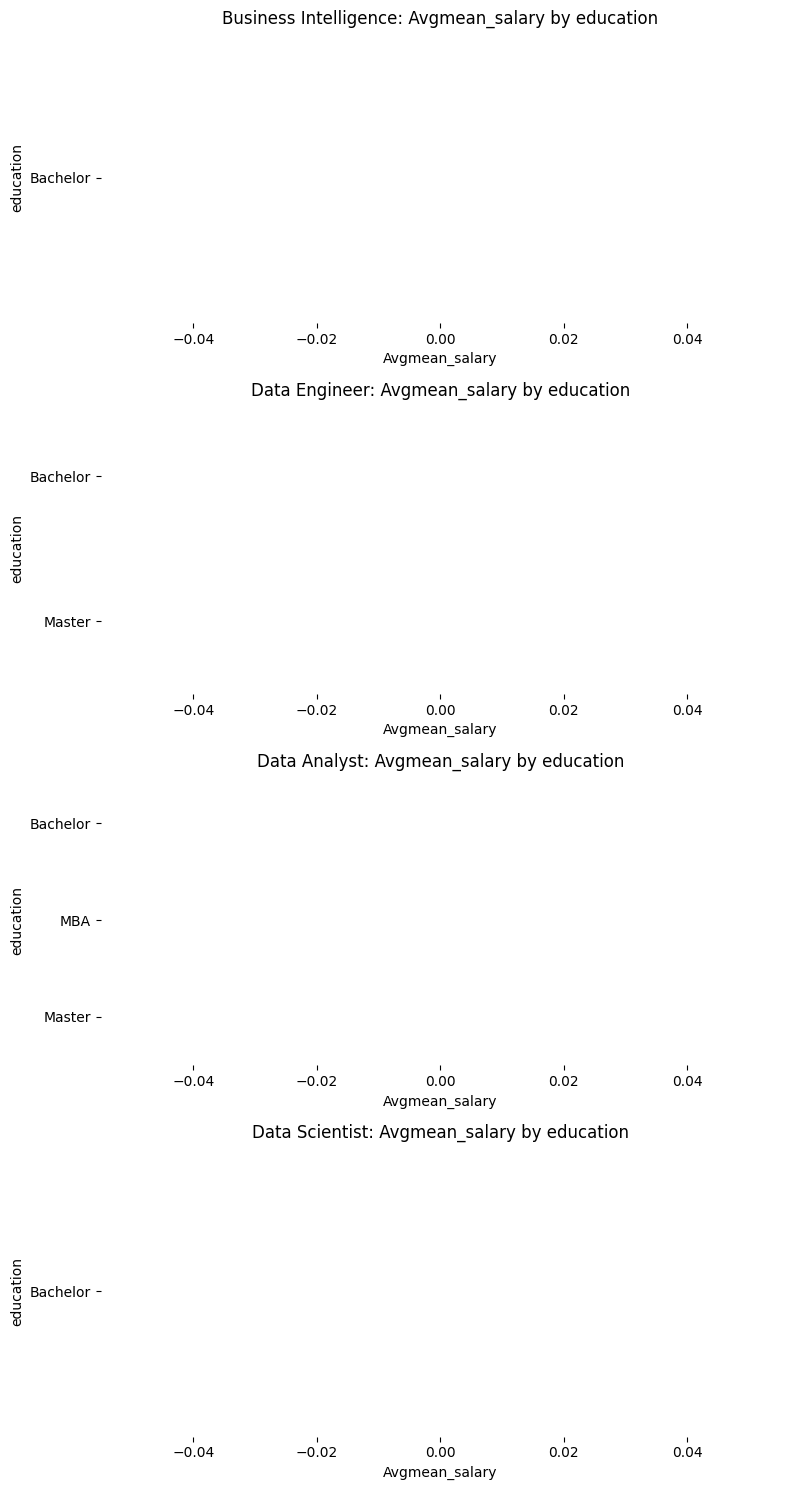

In [28]:
plot_multiple_bars(columns_education,category='job_group',figsize=(8,15),aggregate_column='mean_salary')

## Salario segun Experiencia

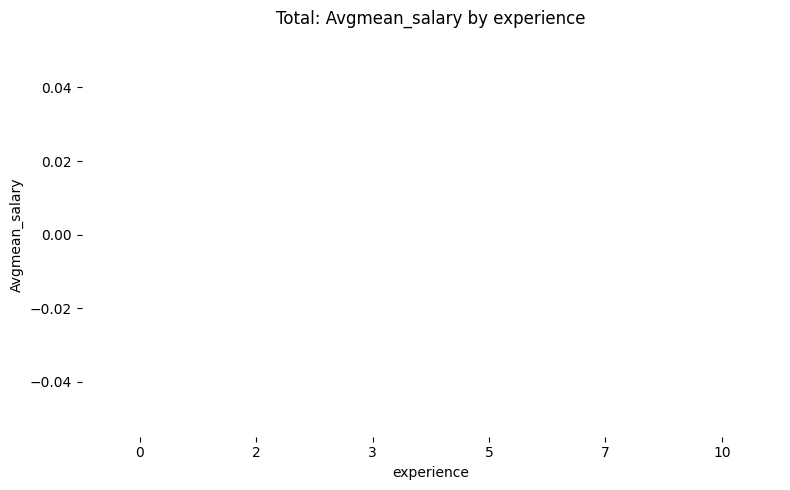

In [29]:
plot_multiple_bars(columns_experience,figsize=(8,5), x_y= True, aggregate_column='mean_salary')

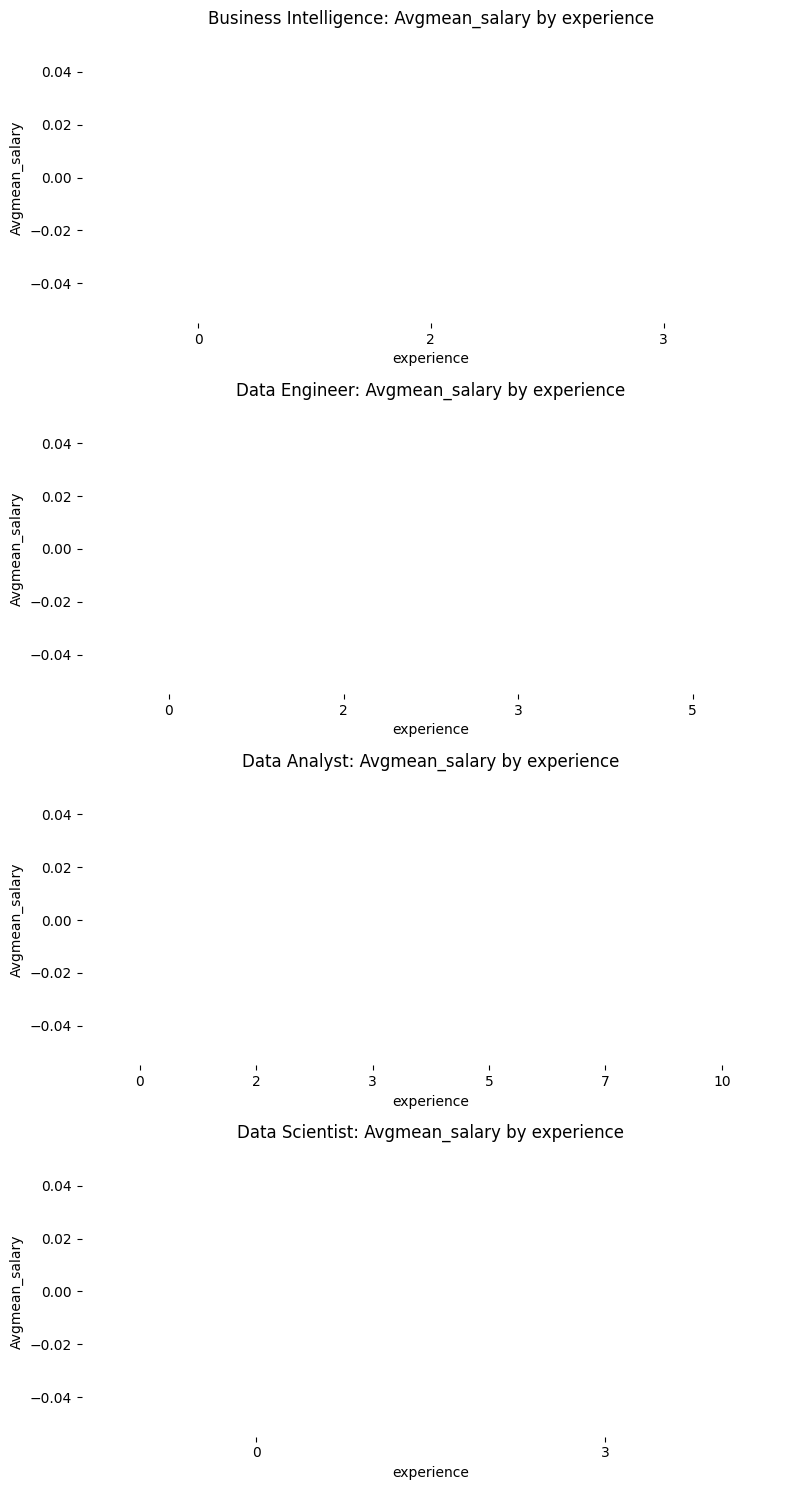

In [30]:
plot_multiple_bars(columns_experience,category='job_group',figsize=(8,15), x_y= True, aggregate_column='mean_salary')

## Habilidades mejor pagadas

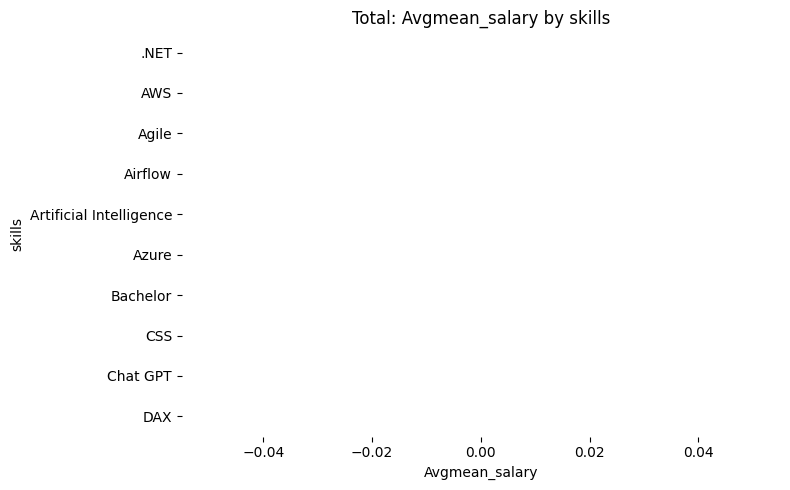

In [31]:
plot_multiple_bars(columns_skills,figsize=(8,5), list_values=True, top_10=True, aggregate_column='mean_salary')

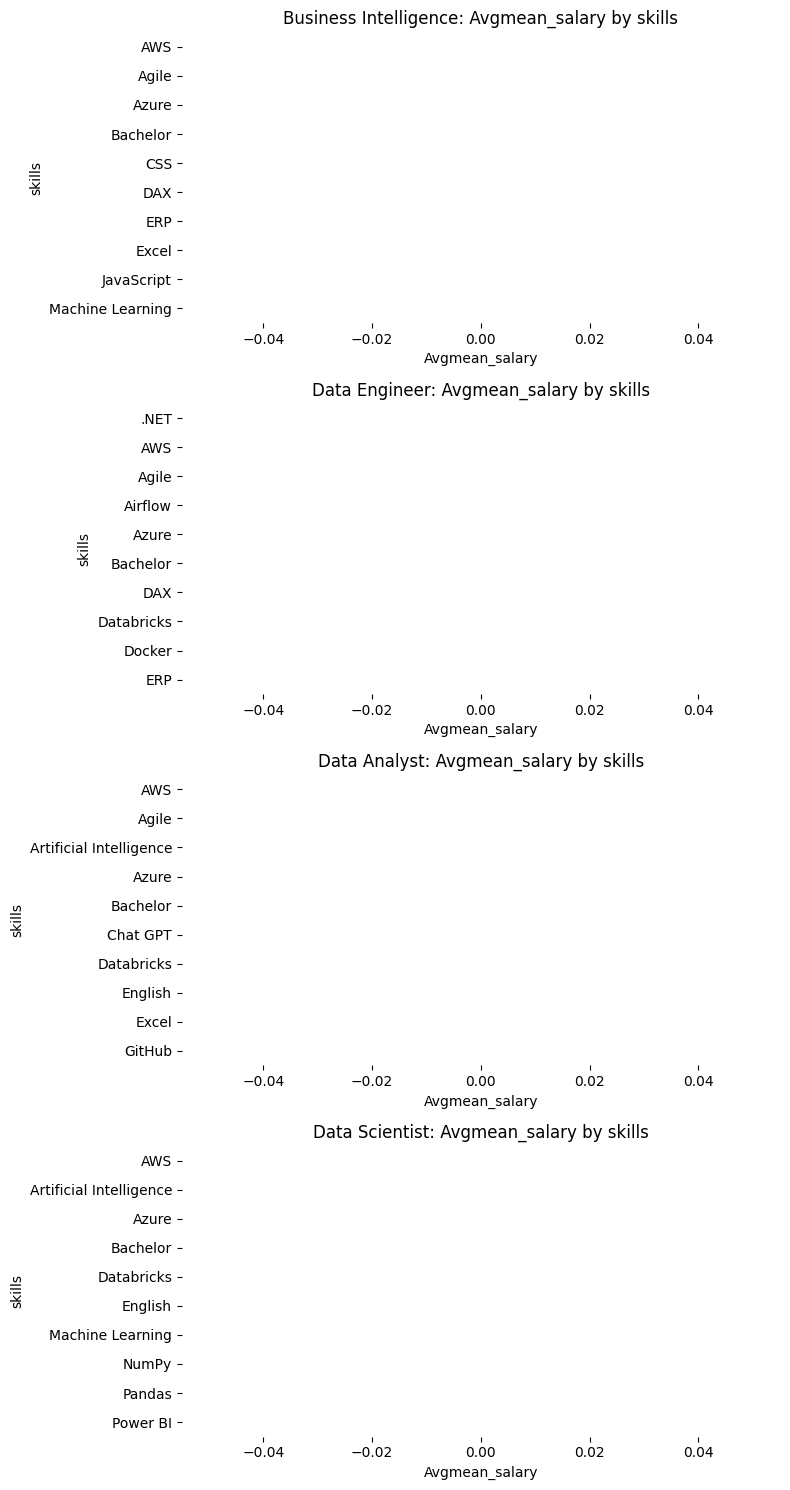

In [32]:
plot_multiple_bars(columns_skills,category='job_group',figsize=(8,15), list_values=True, top_10=True, aggregate_column='mean_salary')

## Salario segun el lenguaje de programacion

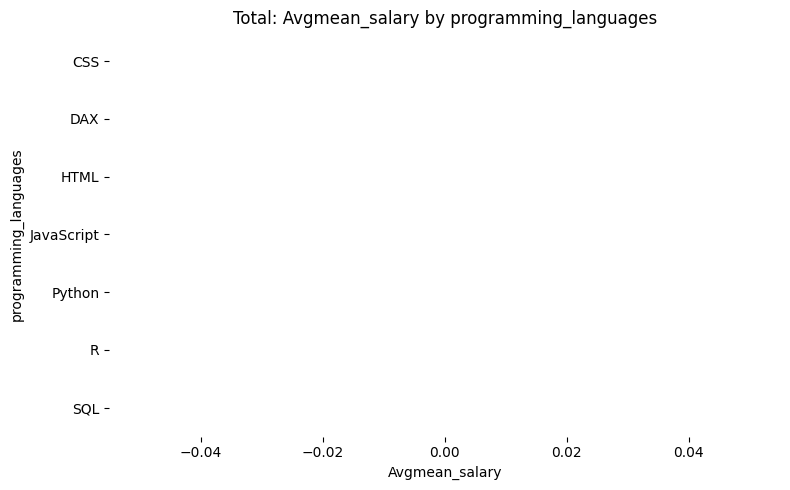

In [33]:
plot_multiple_bars(column_programming_language,figsize=(8,5), list_values=True, top_10=True, aggregate_column='mean_salary')

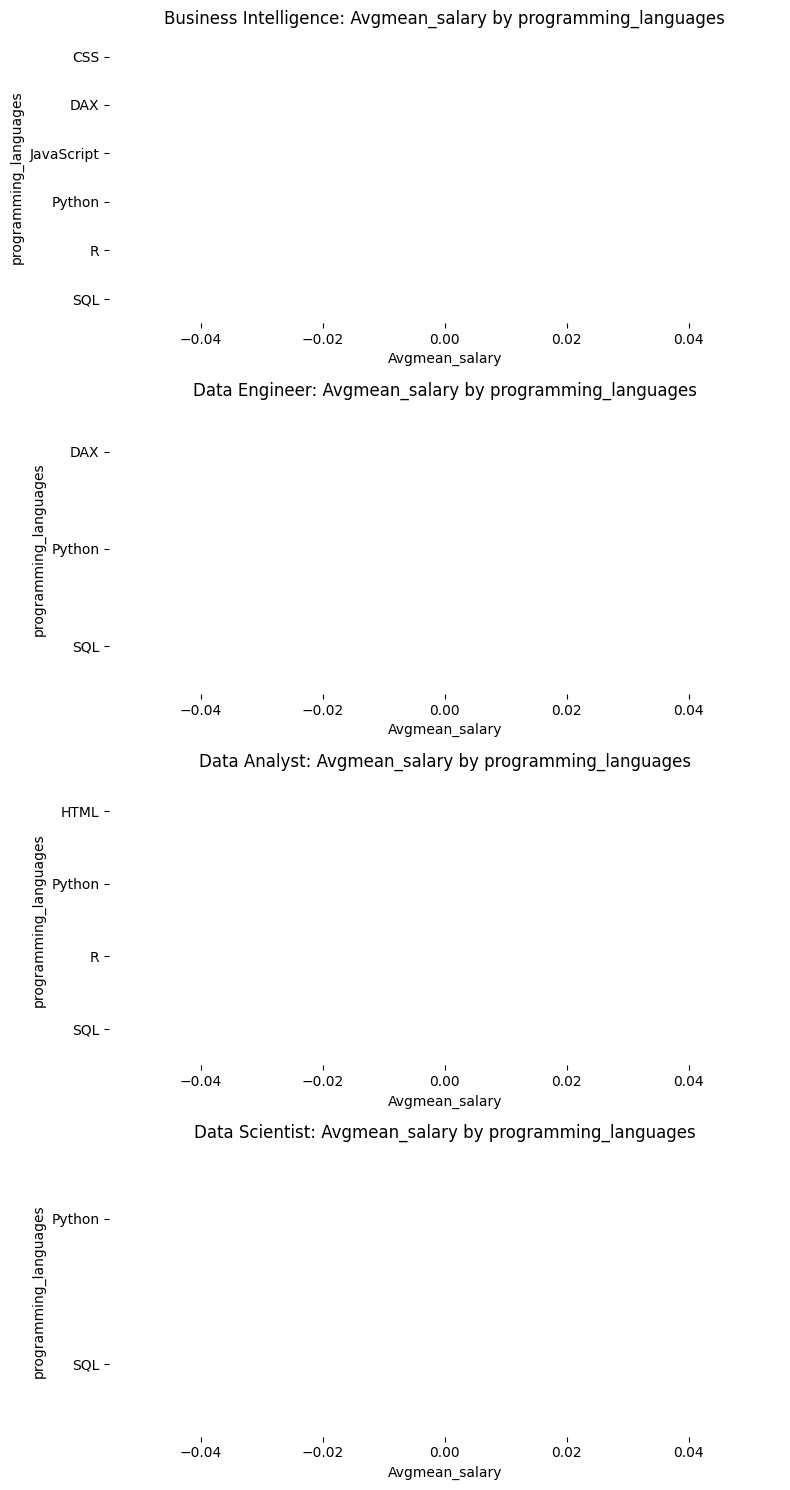

In [34]:
plot_multiple_bars(column_programming_language,category='job_group',figsize=(8,15), list_values=True, top_10=True, aggregate_column='mean_salary')

## Salario segun el idioma

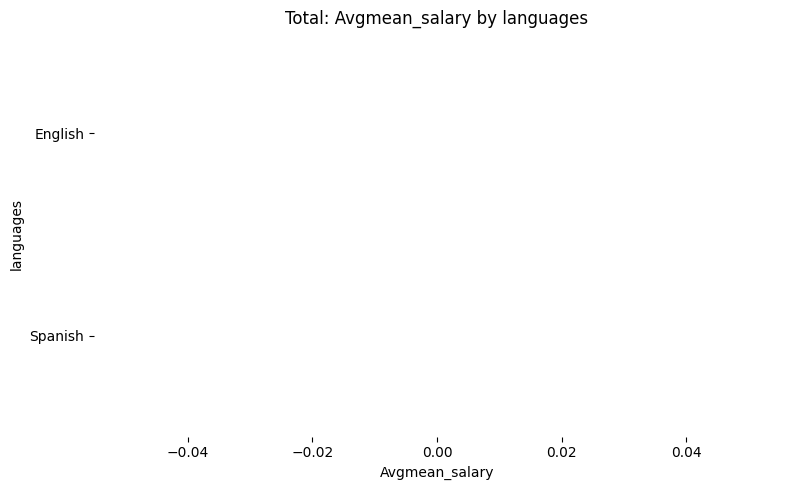

In [35]:
plot_multiple_bars(column_languages,figsize=(8,5), list_values=True, top_10=True, aggregate_column='mean_salary')

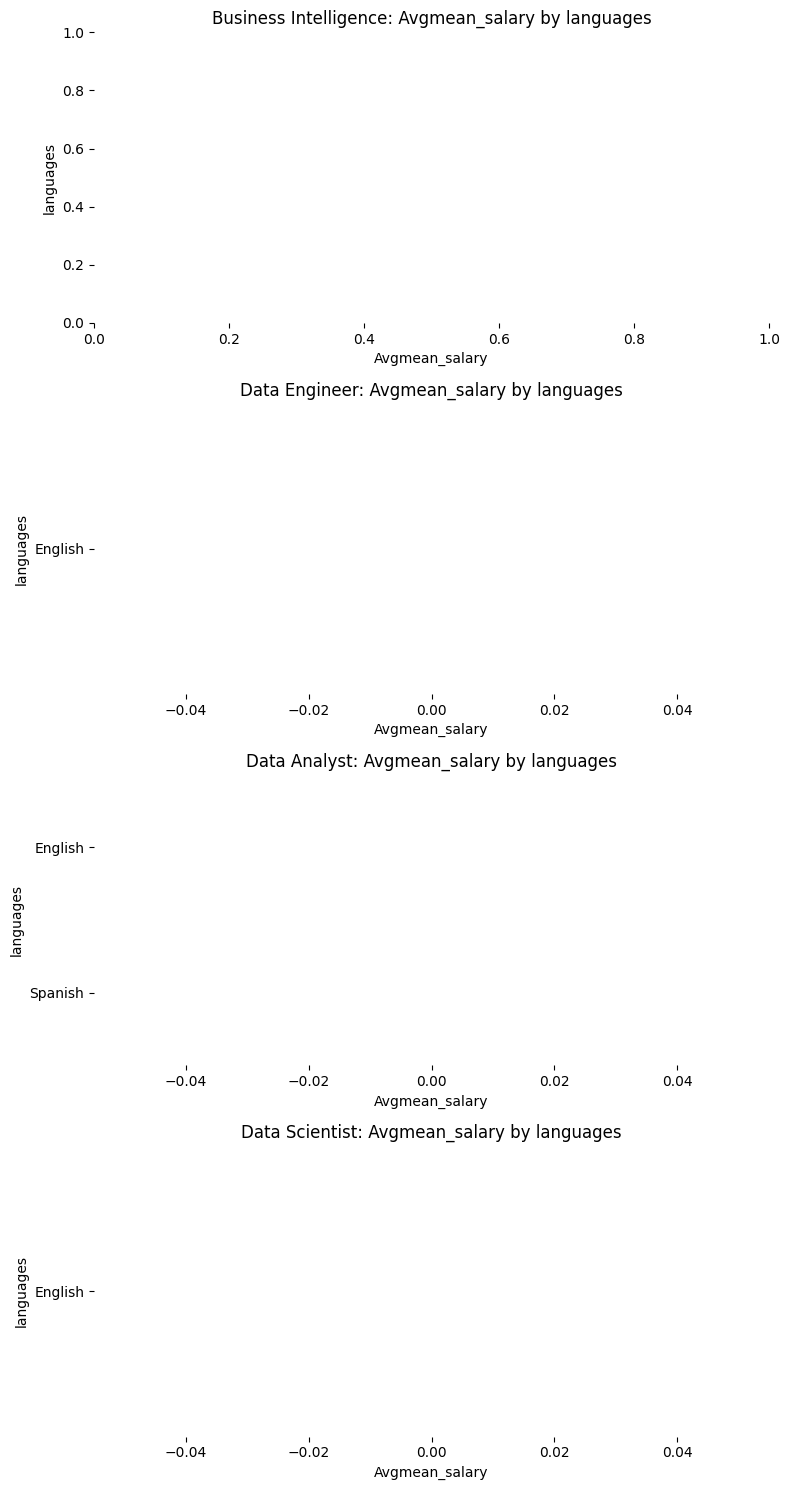

In [36]:
plot_multiple_bars(column_languages,category='job_group',figsize=(8,15), list_values=True, top_10=True, aggregate_column='mean_salary')

# Modalidad de trabajo

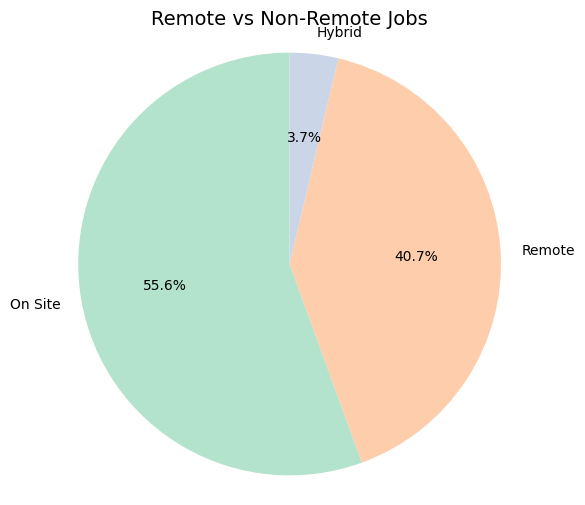

In [37]:
def plot_remote_distribution(df,column_name,title,category=None,figsize=(6,6)):

    def create_pie(data,chart_title,ax):
        counts = data.value_counts()
        ax.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=plt.cm.Pastel2.colors,
            startangle=90
        )
        ax.set_title(chart_title,fontsize=14)
        ax.axis('equal')
    
    if category:
        unique_categories = df[category].unique()
        n_categories = len(unique_categories)

        fig,axes = plt.subplots(n_categories,1,figsize=figsize)
        if n_categories == 1:
            axes = [axes]

        for i, job_group in enumerate(unique_categories):
            df_grouped = df[df[category] == job_group]
            title_grouped = f"{job_group}:{title}"
            create_pie(df_grouped[column_name], title_grouped, axes[i])

        plt.tight_layout()
        plt.show()

    else:

        fig, ax = plt.subplots(figsize=figsize)
        create_pie(df[column_name],title,ax)
        plt.show()

plot_remote_distribution(df=df,column_name='remote',title='Remote vs Non-Remote Jobs')

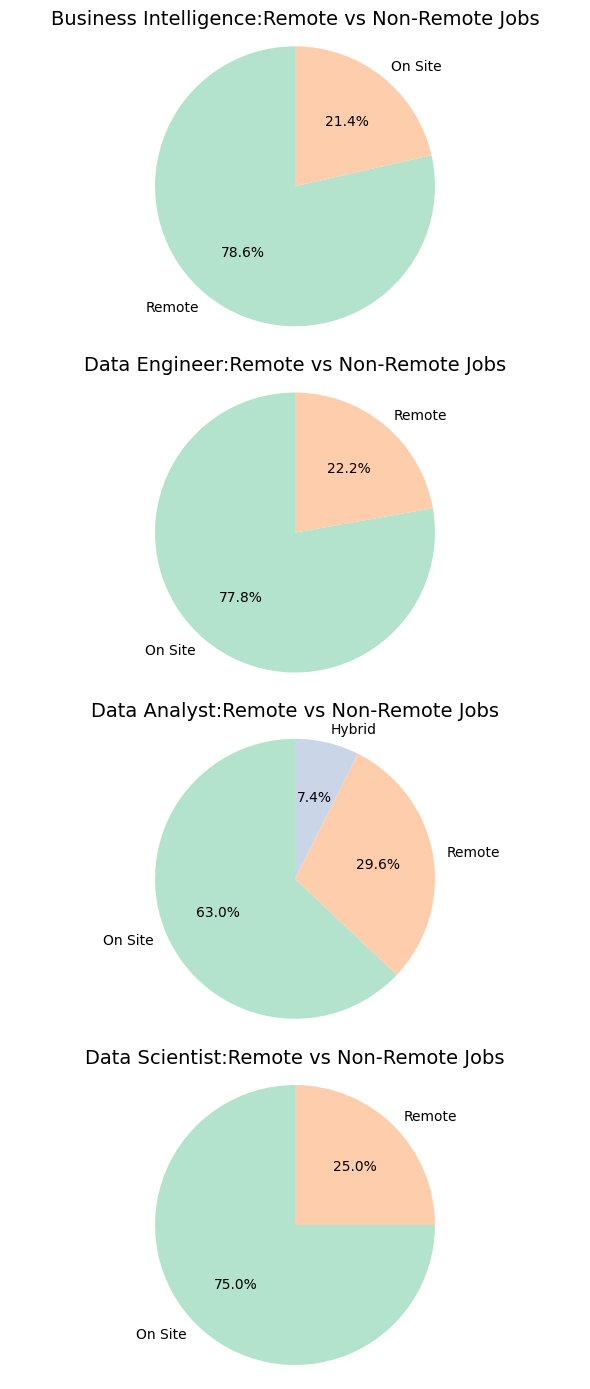

In [38]:
plot_remote_distribution(df=df,column_name='remote',title='Remote vs Non-Remote Jobs', figsize=(6,14),category='job_group')